Number of diseases: 6761
Number of genes: 7878
EXAMPLE INPUT
Disease ID: umls:C0011860
Disease Name: Diabetes Mellitus, Type 2

TOP 10 SIMILAR DISEASES

1. Diabetes Mellitus, Noninsulin-Dependent, 3
   Disease ID: umls:C1863594
   Similarity: 0.9144
   Top genes:
      NIDDM3: 0.2100
   Shared genes:
       NIDDM3

2. Diabetes Mellitus, Noninsulin-Dependent, Type 4
   Disease ID: umls:C1842642
   Similarity: 0.9139
   Top genes:
      NIDDM4: 0.2100
   Shared genes:
       NIDDM4

3. Diabetes Mellitus, Noninsulin-Dependent, 1
   Disease ID: umls:C1832544
   Similarity: 0.9012
   Top genes:
      NIDDM1: 0.2100
      CAPN10: 0.2100
   Shared genes:
       CAPN10

4. MODY, Type 6
   Disease ID: umls:C1853371
   Similarity: 0.7952
   Top genes:
      NEUROD1: 0.4200
   Shared genes:
       NEUROD1

5. Diabetes Mellitus, Experimental
   Disease ID: umls:C0011853
   Similarity: 0.7876
   Top genes:
      SLC9A3: 0.3100
      IL1B: 0.3100
      PTGS2: 0.3100
      VEGFA: 0.3100
      UCP2: 0

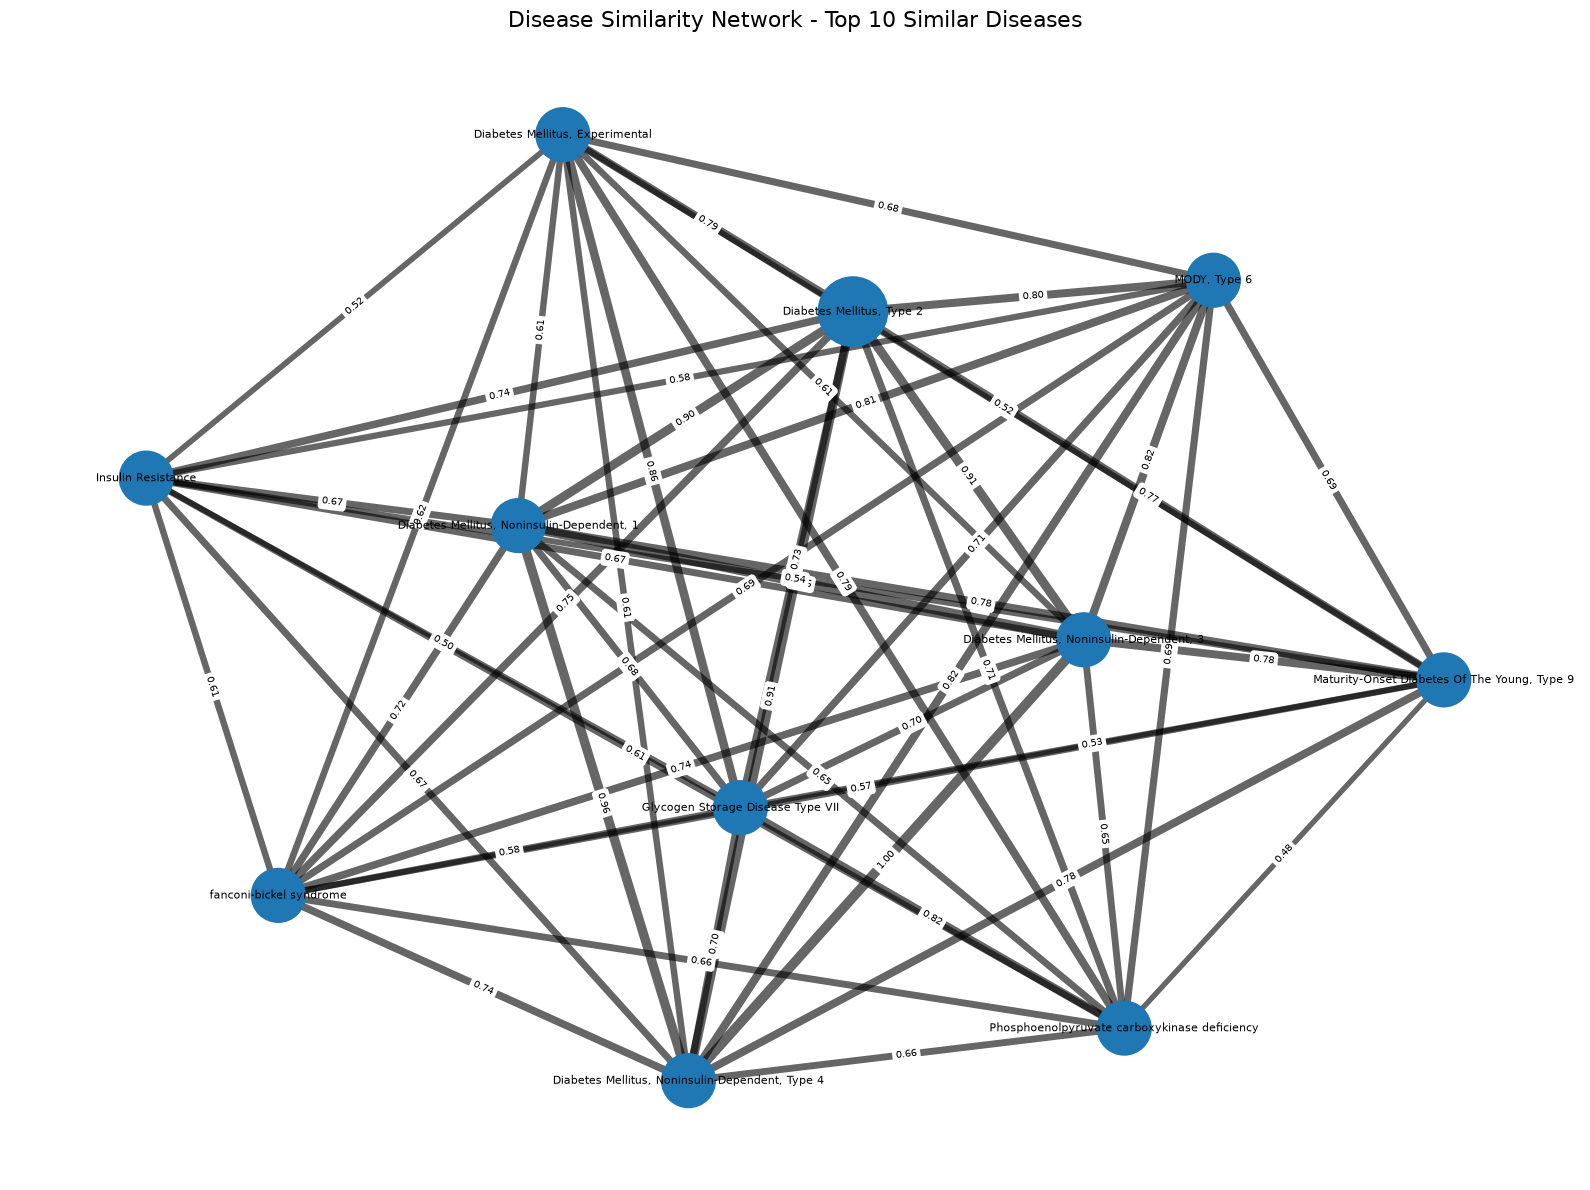


PROCESS COMPLETE


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD
from scipy.stats import spearmanr


DISGENET_FILE = "curated_gene_disease_associations.txt"
K_NEIGHBORS = 10
SVD_COMPONENTS = 128
TARGET_DISEASE = "umls:C0011860"


df = pd.read_csv(DISGENET_FILE, sep="\t", dtype=str, low_memory=False)

score_col = None
for c in ["score", "Score", "score "]:
    if c in df.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError("Score column not found.")

df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
df = df.dropna(subset=["diseaseId", "geneSymbol", score_col])

diseases = df["diseaseId"].unique().tolist()
genes = df["geneSymbol"].unique().tolist()

disease2idx = {disease: i for i, disease in enumerate(diseases)}
gene2idx = {gene: i for i, gene in enumerate(genes)}
idx2disease = {i: disease for disease, i in disease2idx.items()}
idx2gene = {i: gene for gene, i in gene2idx.items()}

N_d = len(diseases)
N_g = len(genes)

print("Number of diseases:", N_d)
print("Number of genes:", N_g)


features = np.zeros((N_d, N_g), dtype=np.float32)

for _, row in df.iterrows():
    disease_index = disease2idx[row["diseaseId"]]
    gene_index = gene2idx[row["geneSymbol"]]
    score = float(row[score_col])
    if score > features[disease_index, gene_index]:
        features[disease_index, gene_index] = score


gene_frequency = np.count_nonzero(features > 0, axis=0)
idf = np.log((N_d + 1) / (gene_frequency + 1)) + 1
weighted_features = features * idf
weighted_features = normalize(weighted_features, norm="l2", axis=1).astype(np.float32)


baseline_knn = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="cosine", algorithm="brute")
baseline_knn.fit(weighted_features)


n_components = min(SVD_COMPONENTS, N_d - 1, N_g - 1)

svd = TruncatedSVD(n_components=n_components, random_state=42)
embeddings = svd.fit_transform(weighted_features)
embeddings = normalize(embeddings, norm="l2", axis=1).astype(np.float32)


knn_model = NearestNeighbors(n_neighbors=K_NEIGHBORS + 1, metric="cosine", algorithm="brute")
knn_model.fit(embeddings)


disease_names_map = df[["diseaseId", "diseaseName"]].drop_duplicates("diseaseId").set_index("diseaseId")["diseaseName"].to_dict()


def find_similar_diseases(disease_id, top_k=10, top_genes=5):
    if disease_id not in disease2idx:
        raise ValueError(f"Disease {disease_id} not found.")

    disease_index = disease2idx[disease_id]
    distances, indices = knn_model.kneighbors(embeddings[disease_index].reshape(1, -1), n_neighbors=top_k + 1)
    target_genes = set(np.where(features[disease_index] > 0)[0])
    results = []

    for distance, index in zip(distances[0], indices[0]):
        if index == disease_index:
            continue

        similarity = 1 - distance
        similar_disease_id = idx2disease[index]
        gene_scores = features[index]
        top_gene_indices = gene_scores.argsort()[-top_genes:][::-1]
        top_genes_list = [(idx2gene[i], float(gene_scores[i])) for i in top_gene_indices if gene_scores[i] > 0]
        similar_genes = set(np.where(features[index] > 0)[0])
        shared_gene_indices = target_genes & similar_genes
        shared_genes = [idx2gene[i] for i in shared_gene_indices]

        results.append({
            "disease_id": similar_disease_id,
            "disease_name": disease_names_map.get(similar_disease_id, "Unknown"),
            "similarity": float(similarity),
            "top_genes": top_genes_list,
            "shared_genes": shared_genes
        })

        if len(results) == top_k:
            break

    return results


def evaluate_model(top_k=10, max_diseases=500):
    precision_scores = []
    recall_scores = []
    f1_scores = []
    shared_gene_scores = []
    similarity_scores = []
    predicted_similarities = []
    actual_similarities = []

    evaluation_count = min(N_d, max_diseases)

    for disease_index in range(evaluation_count):
        target_genes = set(np.where(features[disease_index] > 0)[0])

        if len(target_genes) == 0:
            continue

        distances, indices = knn_model.kneighbors(embeddings[disease_index].reshape(1, -1), n_neighbors=top_k + 1)

        retrieved = []

        for distance, index in zip(distances[0], indices[0]):
            if index == disease_index:
                continue
            retrieved.append((distance, index))
            if len(retrieved) == top_k:
                break

        relevant_diseases = set()

        for other_index in range(N_d):
            if other_index == disease_index:
                continue

            other_genes = set(np.where(features[other_index] > 0)[0])

            if target_genes & other_genes:
                relevant_diseases.add(other_index)

        if len(relevant_diseases) == 0:
            continue

        retrieved_indices = {index for _, index in retrieved}
        true_positive = len(retrieved_indices & relevant_diseases)

        precision = true_positive / len(retrieved_indices)
        recall = true_positive / len(relevant_diseases)

        if precision + recall > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = 0

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)

        disease_shared_genes = []

        for distance, index in retrieved:
            other_genes = set(np.where(features[index] > 0)[0])
            shared_genes = target_genes & other_genes
            disease_shared_genes.append(len(shared_genes))

            predicted_similarity = 1 - distance
            union_genes = target_genes | other_genes

            if len(union_genes) > 0:
                jaccard_similarity = len(shared_genes) / len(union_genes)
            else:
                jaccard_similarity = 0

            predicted_similarities.append(predicted_similarity)
            actual_similarities.append(jaccard_similarity)

        shared_gene_scores.append(np.mean(disease_shared_genes))
        similarity_scores.append(np.mean([1 - distance for distance, _ in retrieved]))

    if len(predicted_similarities) > 1:
        spearman_correlation, _ = spearmanr(predicted_similarities, actual_similarities)
    else:
        spearman_correlation = 0

    metrics = {
        "Precision@10": np.mean(precision_scores),
        "Recall@10": np.mean(recall_scores),
        "F1@10": np.mean(f1_scores),
        "Average Shared Genes@10": np.mean(shared_gene_scores),
        "Mean Similarity@10": np.mean(similarity_scores),
        "Spearman Correlation": spearman_correlation
    }

    return metrics


def create_disease_network(target_disease, results):
    graph = nx.Graph()

    target_name = disease_names_map.get(target_disease, target_disease)
    graph.add_node(target_name, node_type="target")

    for result in results:
        disease_name = result["disease_name"]
        similarity = result["similarity"]
        graph.add_node(disease_name, node_type="similar")
        graph.add_edge(target_name, disease_name, weight=similarity)

    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            disease_a = results[i]["disease_id"]
            disease_b = results[j]["disease_id"]

            index_a = disease2idx[disease_a]
            index_b = disease2idx[disease_b]

            similarity = float(embeddings[index_a] @ embeddings[index_b])

            if similarity > 0.1:
                graph.add_edge(results[i]["disease_name"], results[j]["disease_name"], weight=similarity)

    positions = nx.spring_layout(graph, seed=42, weight="weight", k=2.0)

    plt.figure(figsize=(16, 12))

    node_sizes = [2500 if node == target_name else 1500 for node in graph.nodes()]
    edge_weights = [graph[u][v]["weight"] for u, v in graph.edges()]
    scaled_edge_widths = [1 + (weight * 6) for weight in edge_weights]

    nx.draw_networkx_nodes(graph, positions, node_size=node_sizes)
    nx.draw_networkx_edges(graph, positions, width=scaled_edge_widths, alpha=0.6)
    nx.draw_networkx_labels(graph, positions, font_size=8)

    edge_labels = {(u, v): f"{data['weight']:.2f}" for u, v, data in graph.edges(data=True)}
    nx.draw_networkx_edge_labels(graph, positions, edge_labels=edge_labels, font_size=7)

    plt.title("Disease Similarity Network - Top 10 Similar Diseases", fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


print("=" * 70)
print("EXAMPLE INPUT")
print("=" * 70)
print("Disease ID:", TARGET_DISEASE)
print("Disease Name:", disease_names_map.get(TARGET_DISEASE, "Unknown"))

results = find_similar_diseases(TARGET_DISEASE, top_k=10, top_genes=5)

print("\n" + "=" * 70)
print("TOP 10 SIMILAR DISEASES")
print("=" * 70)

for i, result in enumerate(results, 1):
    print(f"\n{i}. {result['disease_name']}")
    print("   Disease ID:", result["disease_id"])
    print("   Similarity:", f"{result['similarity']:.4f}")
    print("   Top genes:")

    for gene, score in result["top_genes"]:
        print(f"      {gene}: {score:.4f}")

    print("   Shared genes:")

    if result["shared_genes"]:
        print("      ", ", ".join(result["shared_genes"][:20]))
    else:
        print("      None")

print("\n" + "=" * 70)
print("EVALUATION METRICS")
print("=" * 70)
metrics = evaluate_model(top_k=10, max_diseases=500)
print("Precision@10:", f"{metrics['Precision@10']:.4f}")
print("Recall@10:", f"{metrics['Recall@10']:.4f}")
print("F1@10:", f"{metrics['F1@10']:.4f}")
print("Average Shared Genes@10:", f"{metrics['Average Shared Genes@10']:.4f}")
print("Mean Similarity@10:", f"{metrics['Mean Similarity@10']:.4f}")

print("\n" + "=" * 70)
print("DISEASE SIMILARITY NETWORK")
print("=" * 70)
create_disease_network(TARGET_DISEASE, results)

print("\n" + "=" * 70)
print("PROCESS COMPLETE")
print("=" * 70)